# Muscule Fatigue Problem

# Install the right Kernel

In [1]:
## You have to execute this command on the terminal: pip install ipykernel. Then select this kernel for this file on your IDE. 

import sys
print(sys.executable)

/home/simonsloan/Universidad/Semestre5/InteligenciaArtificial/Report2ArtificialInteligence/venv/bin/python


## Import some libreries

In [26]:
from datasets import load_dataset
import pandas as pd
import numpy as np
from PIL import Image
from IPython.display import display

## Load dataset

In [27]:
dataset = load_dataset("YominE/Muscle_Fatigue_Cycling")

## We got to understand how data comes

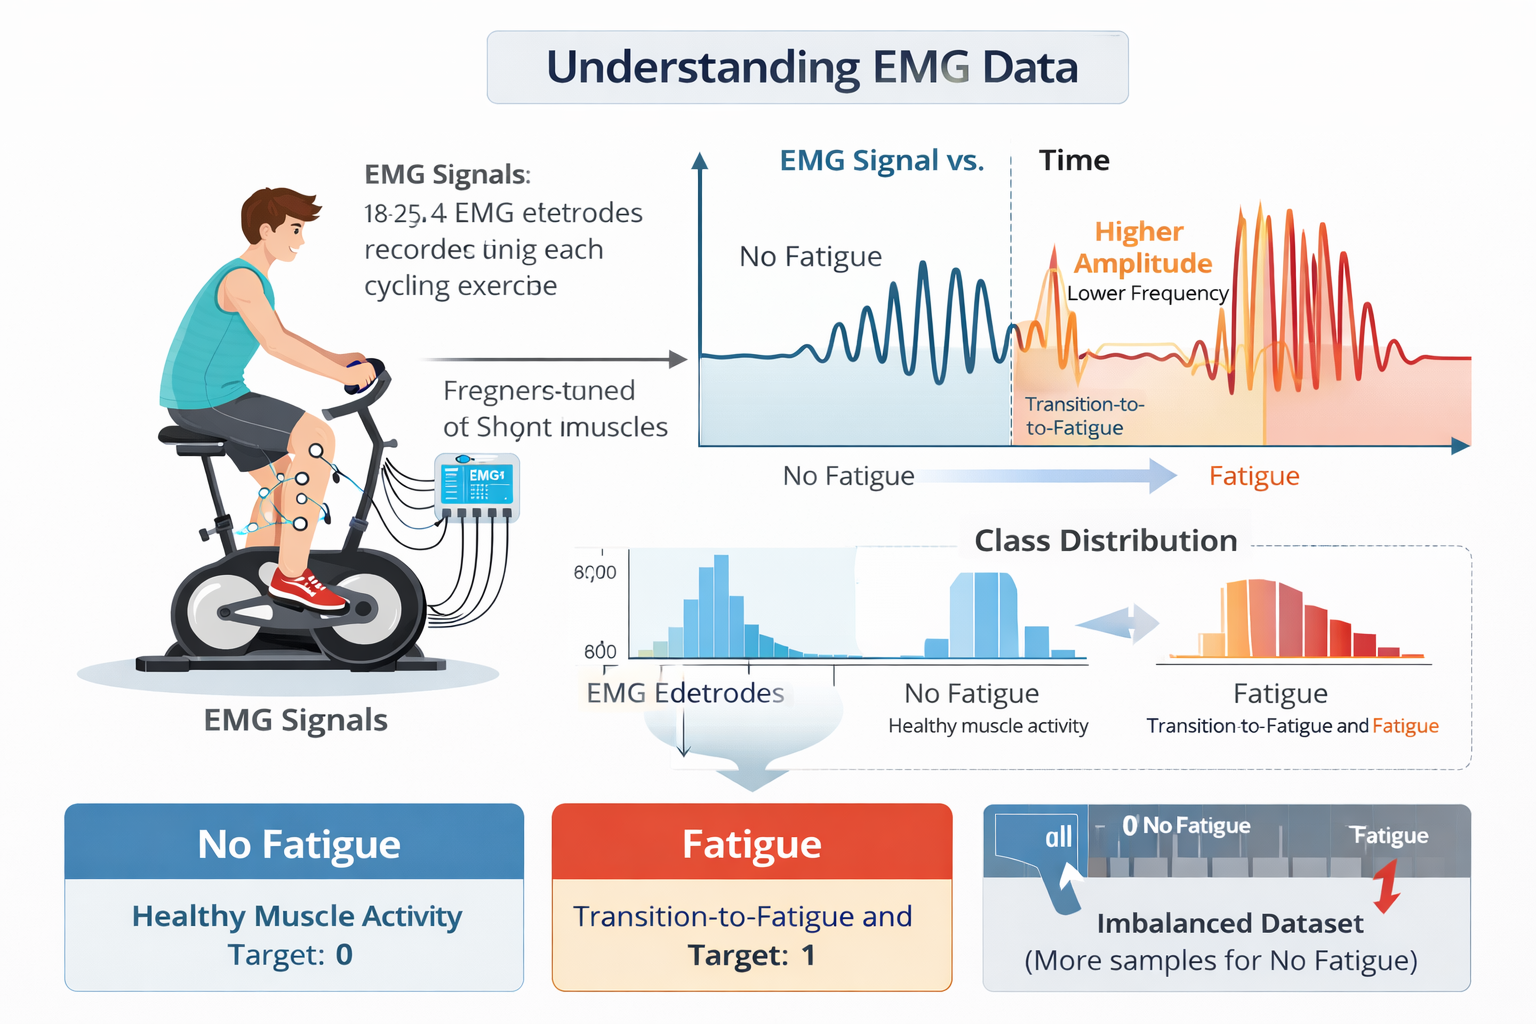

,Time,Right Rectus femoris,Left Gluteus maximus,Left Gastrocnemius medialis,Left Semitendinosus,Left Biceps femoris caput longus,Right Vastus medialis,Right Tibialis anterior,Left Gastrocnemius lateralis,Target
0,0.000,-0.000264,-0.000015,0.000344,0.000108,0.000182,0.000401,0.000267,-0.000236,0
1,0.001,-0.001002,-0.000045,0.001342,0.000429,0.000712,0.002234,0.001234,-0.001108,0
2,0.002,-0.002173,-0.000034,0.002944,0.001133,0.001692,0.007634,0.003457,-0.003277,0
3,0.003,-0.002676,0.000185,0.003504,0.002319,0.002820,0.017656,0.006587,-0.006940,0
4,0.004,-0.000844,0.000785,0.000426,0.003950,0.003729,0.028542,0.008889,-0.011310,0


In [28]:
df = dataset["train"].to_pandas()
img = Image.open("images/UnderstandingData.png")
display(img)
df.head()

## Preliminary analysis

In [29]:

df["Target"] = df["Target"].replace(2, 1)

X = df.drop(columns=["Target"])
y = df["Target"]

# As all X data is numeric, then we could skip this pass. But we do it for good practices

numerical_cols = X.select_dtypes(include='number').columns.tolist()

## Feature Engineering. Create Windows

In [40]:
window_size = 1000
overlap = 500
step = window_size - overlap  

windows = []

for start in range(0, len(df) - window_size + 1, step):
    end = start + window_size
    window = df.iloc[start:end]
    windows.append(window)

len(windows)


6003

## Feature Engenieering. Get features 

### Define functions for getting our metrics

- Root Mean Square -> Muscular Energy 
- Mean Absolute Value -> Average intensity
- VAR -> Variability
- Waveform -> Signal Complexity
- Zero Crossing -> Frecuency Changes 
- Median Frecuency -> Spectral Shift
- Mean Frecuency -> Mean Frecuency Energy


In [31]:
def get_rms(signal):
    
    squared_signal = signal ** 2
    mean_squared = np.mean(squared_signal)
    rms_value = np.sqrt(mean_squared)

    return rms_value

def get_mav(signal):

    absolute_signal = np.abs(signal)
    mav_value = np.mean(absolute_signal)

    return mav_value

def get_variance(signal):

    variance_value = np.var(signal)

    return variance_value

def get_waveform_length(signal):

    consecutive_differences = np.diff(signal)
    absolute_differences = np.abs(consecutive_differences)
    waveform_length = np.sum(absolute_differences)

    return waveform_length

def get_zero_crossings(signal):

    signal_sign = np.sign(signal)
    sign_changes = np.diff(signal_sign)
    zero_crossings = np.sum(sign_changes != 0)

    return zero_crossings

def get_mean_frequency(signal, sampling_rate):

    frequencies = np.fft.rfftfreq(len(signal), d=1 / sampling_rate)

    spectrum = np.fft.rfft(signal)
    power_spectrum = np.abs(spectrum) ** 2

    weighted_sum = np.sum(frequencies * power_spectrum)
    total_power = np.sum(power_spectrum)

    mean_frequency = weighted_sum / total_power

    return mean_frequency

def get_median_frequency(signal, sampling_rate):

    spectrum = np.fft.rfft(signal)
    power_spectrum = np.abs(spectrum) ** 2

    frequencies = np.fft.rfftfreq(len(signal), d=1 / sampling_rate)

    cumulative_power = np.cumsum(power_spectrum)
    half_power = cumulative_power[-1] / 2

    median_index = np.where(cumulative_power >= half_power)[0][0]
    median_frequency = frequencies[median_index]

    return median_frequency

### Single function to get all new features for a channel

In [32]:
def extract_emg_features(signal, sampling_rate):

    features = {}

    features["RMS"] = get_rms(signal)
    features["MAV"] = get_mav(signal)
    features["VAR"] = get_variance(signal)
    features["WL"] = get_waveform_length(signal)
    features["ZC"] = get_zero_crossings(signal)
    features["MNF"] = get_mean_frequency(signal, sampling_rate)
    features["MDF"] = get_median_frequency(signal, sampling_rate)

    return features

### Create new features 

In [38]:
emg_cols = df.drop(columns=["Time", "Target"]).columns

feature_rows = []

for window in windows:

    row = {}

    for col in emg_cols:

        signal = window[col].values

        features = extract_emg_features(signal, window_size)

        for name, value in features.items():
            row[f"{name}_{col}"] = value

    # asignar etiqueta a la ventana
    row["Target"] = window["Target"].mode()[0]

    feature_rows.append(row)



### Analize new dataset

In [41]:
features_df = pd.DataFrame(feature_rows)
len(features_df)
features_df.head()

,RMS_Right Rectus femoris,MAV_Right Rectus femoris,VAR_Right Rectus femoris,WL_Right Rectus femoris,ZC_Right Rectus femoris,MNF_Right Rectus femoris,MDF_Right Rectus femoris,RMS_Left Gluteus maximus,MAV_Left Gluteus maximus,VAR_Left Gluteus maximus,...,MNF_Right Tibialis anterior,MDF_Right Tibialis anterior,RMS_Left Gastrocnemius lateralis,MAV_Left Gastrocnemius lateralis,VAR_Left Gastrocnemius lateralis,WL_Left Gastrocnemius lateralis,ZC_Left Gastrocnemius lateralis,MNF_Left Gastrocnemius lateralis,MDF_Left Gastrocnemius lateralis,Target
0,0.011706,0.008125,0.000137,3.072632,123,55.438515,46.0,0.003989,0.003260,0.000016,...,94.415324,96.0,0.025655,0.019441,0.000658,6.501237,120,41.725986,15.0,0
1,0.012752,0.008979,0.000163,3.352470,120,55.399996,50.0,0.003945,0.003207,0.000016,...,93.177823,95.0,0.026479,0.020276,0.000701,6.357688,108,40.322705,14.0,0
2,0.014023,0.010118,0.000197,3.886684,111,57.772974,54.0,0.004223,0.003398,0.000018,...,93.143118,96.0,0.031409,0.021678,0.000986,11.258436,149,78.891486,76.0,0
3,0.016186,0.011668,0.000262,4.405287,107,55.984848,53.0,0.004316,0.003455,0.000019,...,92.322459,95.0,0.033080,0.022561,0.001094,11.895030,155,80.664175,75.0,0
4,0.014820,0.010151,0.000220,3.836192,121,56.101088,50.0,0.004209,0.003354,0.000018,...,92.282649,92.0,0.026209,0.020389,0.000687,7.276616,101,55.348969,50.0,0
